In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv('cleaned_data.csv')
data.head()

,Unnamed: 0,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date,income_rounded,signup_date_formatted,last_purchase_date_formatted
0,1,2,69,50200,252.214693,Male,North,27,Toys,14.402036,14-03-2022,03-07-2022,50200,14-03-2022,03-07-2022
1,4,5,60,112300,1528.118235,Female,West,6,Clothing,28.893785,21-04-2021,02-06-2021,112300,21-04-2021,02-06-2021
2,5,6,25,62000,1024.023200,Male,West,5,Home & Garden,14.360273,18-11-2021,06-07-2023,62000,18-11-2021,06-07-2023
3,6,7,78,90500,1283.045712,Female,East,27,Home & Garden,48.221228,11-06-2022,01-02-2023,90500,11-06-2022,01-02-2023
4,7,8,38,81000,1970.645619,Male,East,8,Clothing,70.952806,26-06-2021,21-12-2022,81000,26-06-2021,21-12-2022


In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2220 entries, 0 to 2219
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    2220 non-null   int64  
 1   customer_id                   2220 non-null   int64  
 2   age                           2220 non-null   int64  
 3   income                        2220 non-null   int64  
 4   purchase_amount               2220 non-null   float64
 5   gender                        2220 non-null   object 
 6   region                        2220 non-null   object 
 7   total_purchases               2220 non-null   int64  
 8   preferred_product_category    2220 non-null   object 
 9   customer_loyalty_score        2220 non-null   float64
 10  signup_date                   2220 non-null   object 
 11  last_purchase_date            2220 non-null   object 
 12  income_rounded                2220 non-null   int64  
 13  sig

In [8]:
data.describe()

,Unnamed: 0,customer_id,age,income,purchase_amount,total_purchases,customer_loyalty_score,income_rounded
count,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000
mean,1744.137838,1745.137838,48.309910,70296.576577,1001.993272,24.658108,49.838757,70296.576577
std,1006.335888,1006.335888,17.767498,28989.099861,570.196144,14.236139,28.778469,28989.099861
min,1.000000,2.000000,18.000000,20200.000000,20.369326,1.000000,0.085729,20200.000000
25%,871.750000,872.750000,33.000000,44575.000000,526.563855,13.000000,24.578672,44575.000000
50%,1741.500000,1742.500000,48.000000,70000.000000,1003.636322,24.000000,49.785463,70000.000000
75%,2630.250000,2631.250000,64.000000,96300.000000,1496.388318,37.000000,74.498006,96300.000000
max,3474.000000,3475.000000,79.000000,120000.000000,1999.508096,49.000000,99.935293,120000.000000


C:\Users\user\AppData\Local\Temp\ipykernel_24400\4026738561.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data['customer_loyalty_score'],data['income'],cmap='viridis')


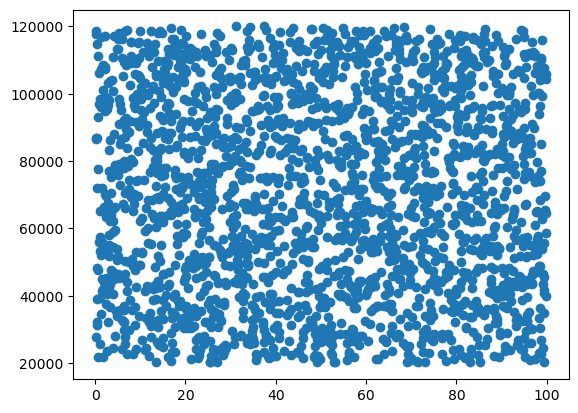

In [46]:
plt.scatter(data['customer_loyalty_score'],data['income'],cmap='viridis')

<Axes: xlabel='customer_loyalty_score', ylabel='income'>

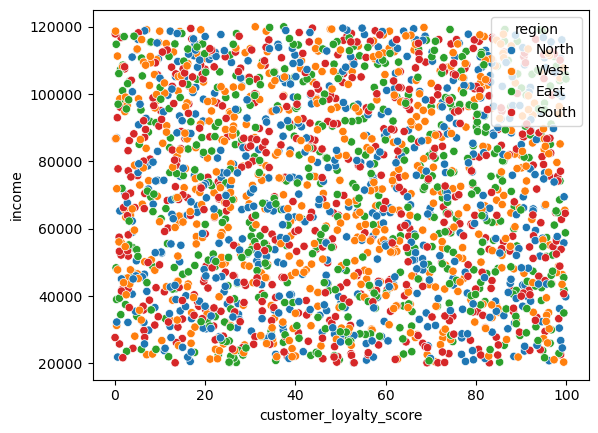

In [61]:
sns.scatterplot(x='customer_loyalty_score',y='income',hue='region',data=data)

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
x=data.drop('region',axis=1)
y=data['region']

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)  
data.columns  

Index(['Unnamed: 0', 'customer_id', 'age', 'income', 'purchase_amount',
       'gender', 'region', 'total_purchases', 'preferred_product_category',
       'customer_loyalty_score', 'signup_date', 'last_purchase_date',
       'income_rounded', 'signup_date_formatted',
       'last_purchase_date_formatted', 'Cluster'],
      dtype='object')

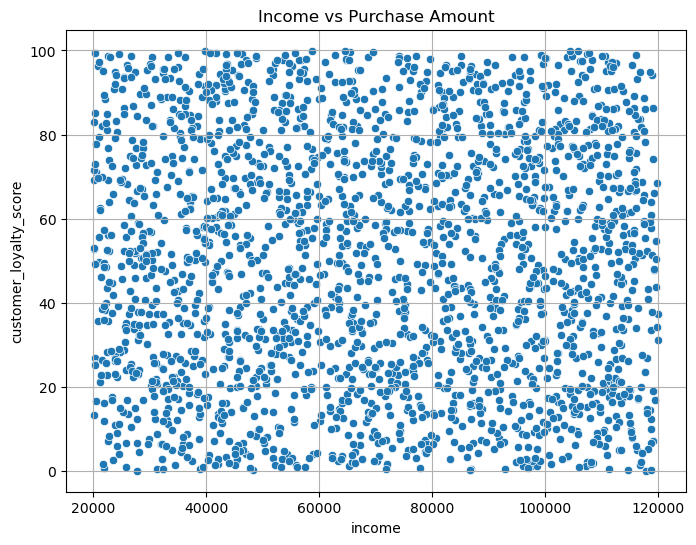

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


## relation between income and purchase amount
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='income', y='customer_loyalty_score')
plt.title("Income vs Purchase Amount")
plt.grid(True)
plt.show()


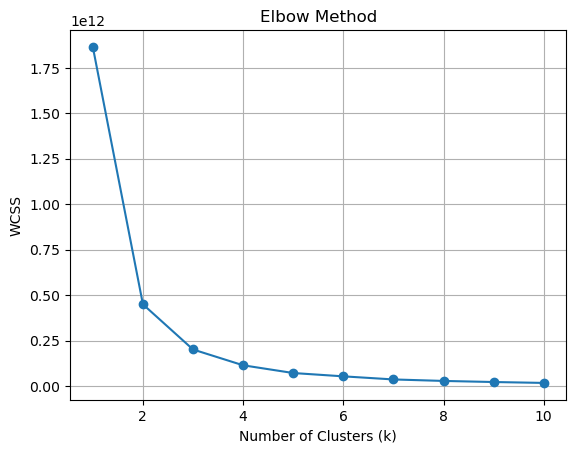

In [65]:
## Elbow Method
X = data[['income', 'customer_loyalty_score']]
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [66]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

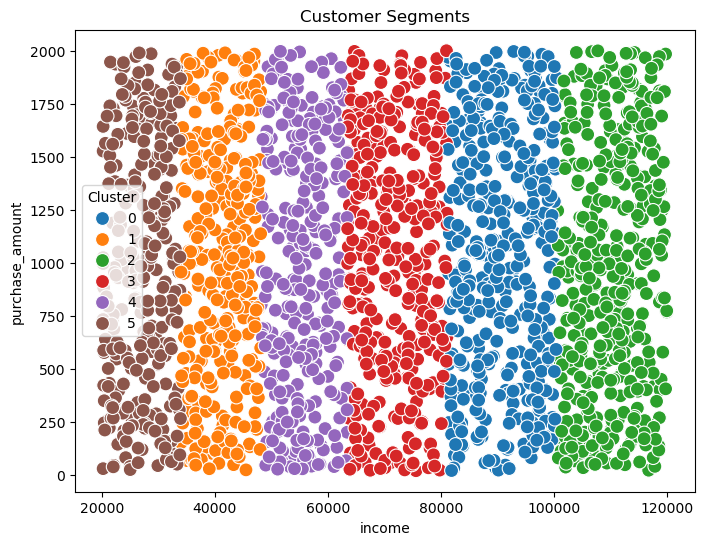

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='income', y='purchase_amount',
                hue='Cluster', palette='tab10', s=100)
plt.title("Customer Segments")
plt.legend(title='Cluster')
plt.show()


                income  customer_loyalty_score
Cluster                                       
0         91018.735892               50.846229
1         41134.421365               51.026361
2        110118.693694               49.174727
3         71664.766839               48.104943
4         55535.806452               51.109082
5         27011.333333               48.917920


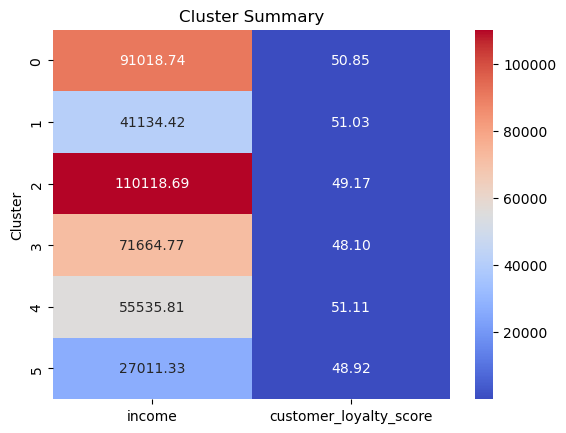

In [68]:
cluster_summary = data.groupby('Cluster')[['income', 'customer_loyalty_score']].mean()
print(cluster_summary)

sns.heatmap(cluster_summary, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cluster Summary")
plt.show()

In [ ]:
## each cluster contain how muxh income
## cluster 2 contain highest income
## cluster 0 contain lowest income
## order of income: cluster 2 > cluster 4 > cluster 1 > cluster 5 > cluster 3 > cluster 0
## loyality score : cluster 1  48.5, cluster 2 47.5, cluster 3 46.2, cluster 5 45.8, cluster 0 44.3

In [69]:
data_point = data.groupby('Cluster').count()

In [ ]:
## data point count in each cluster
data_point

,Unnamed: 0,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date,income_rounded,signup_date_formatted,last_purchase_date_formatted
Cluster,,,,,,,,,,,,,,,
0,443,443,443,443,443,443,443,443,443,443,443,443,443,443,443
1,337,337,337,337,337,337,337,337,337,337,337,337,337,337,337
2,444,444,444,444,444,444,444,444,444,444,444,444,444,444,444
3,386,386,386,386,386,386,386,386,386,386,386,386,386,386,386
4,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310
5,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300


In [ ]:
from kneed import KneeLocator